<a href="https://colab.research.google.com/github/kawastony/grok-notes-version-2/blob/main/L%3D12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================================
# L=12 residual-gated soft-mode + texture-bridge analysis
# Complete Colab notebook using verified 8-component Wilson-Dirac hedgehog
# ============================================================
# Paste cells into Colab in order, or run as a script after installing deps.
#
# POLICY:
# 1. Solve soft modes
# 2. Gate on rel_v = ||Hv-λv||/||v|| <= 1e-6
# 3. Only then compute QT, t1/t2, P1/P2, Brho, BT
# 4. QT alone is defect-local; pair identity needs sharing + multiplet + bridge
# 5. Bridge is geometry, not transport/current
# ============================================================

# ---- Cell 0: setup ----
# !pip -q install numpy scipy pandas matplotlib

import os, json, time, warnings
from dataclasses import dataclass, asdict
from typing import Tuple, Optional, List
from itertools import product

import numpy as np
import pandas as pd
from scipy.sparse import coo_matrix, diags, csr_matrix
from scipy.sparse.linalg import eigsh, LinearOperator
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

BASE_DIR = "/content/l12_texture_bridge"
os.makedirs(f"{BASE_DIR}/modes", exist_ok=True)
os.makedirs(f"{BASE_DIR}/tables", exist_ok=True)
os.makedirs(f"{BASE_DIR}/figs", exist_ok=True)
print("BASE_DIR =", BASE_DIR)

# ---- Cell 1: config ----
@dataclass
class RunConfig:
    L: int = 12
    d_list: Tuple[int, ...] = (1, 3, 5, 6)
    k: int = 4
    eig_tol: float = 1e-8
    eig_maxiter: int = 8000
    rel_residual_gate: float = 1e-6
    core_radius: float = 2.0
    bridge_radius: float = 1.5
    P_thresh: float = 0.02
    BT_thresh: float = 1e-4
    m0: float = 0.3
    v_coup: float = 2.0
    w: float = 1.0
    r_wilson: float = 1.0
    save_modes: bool = True
    use_matrix_free: bool = False  # True if sparse OOM; slower but lower peak RAM

CFG = RunConfig()
print(CFG)

ANALYSIS_POLICY = """
L=12 policy:
1. Solve soft modes.
2. Reject any mode with rel_v > 1e-6.
3. Only then compute texture/bridge/identity observables.
QT < 0 is defect-local anti-alignment — not pair identity alone.
Pair identity = shared P1,P2 + soft multiplet + optional BT bridge.
BT/Brho = corridor geometry, NOT transport/current.
"""
print(ANALYSIS_POLICY)

# ---- Cell 2: algebra (verified 8-component) ----
I2 = np.eye(2, dtype=complex)
sx = np.array([[0., 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
z2 = np.zeros((2, 2), dtype=complex)
alpha4 = [np.block([[z2, s], [s, z2]]) for s in (sx, sy, sz)]
beta4 = np.block([[I2, z2], [z2, -I2]])
ALPHA = [np.kron(a, I2).astype(complex) for a in alpha4]
BETA = np.kron(beta4, I2).astype(complex)
G5mat = np.kron(beta4, I2).astype(complex)  # γ5 = β ⊗ I
MASS_B = [np.kron(beta4, t).astype(complex) for t in (sx, sy, sz)]
EYE8 = np.eye(8, dtype=complex)
G5DIAG = np.diag(G5mat).real.copy()
NSPIN = 8

def hedgehog(x, y, z, cx, cy, cz, L, ww):
    rx = (x - cx) - L * int(round((x - cx) / float(L)))
    ry = (y - cy) - L * int(round((y - cy) / float(L)))
    rz = (z - cz) - L * int(round((z - cz) / float(L)))
    rr = np.sqrt(rx*rx + ry*ry + rz*rz + 1e-16)
    f = np.tanh(rr / ww)
    th = np.arccos(np.clip(rz / rr, -1., 1.))
    ph = np.arctan2(ry, rx)
    hx = np.sin(th) * np.cos(ph)
    hy = np.sin(th) * np.sin(ph)
    hz = np.cos(th)
    dd = rr / np.sqrt(rr*rr + 0.08)
    hx, hy, hz = dd*hx, dd*hy, dd*hz
    n = np.sqrt(hx*hx + hy*hy + hz*hz + 1e-30)
    return f, hx/n, hy/n, hz/n

def pair_centers(L, d):
    """Pair along z, separation d (matches L=10 scans)."""
    z0 = L // 2
    c1 = (L//2, L//2, z0 % L)
    c2 = (L//2, L//2, (z0 + d) % L)
    return c1, c2


def build_sparse_H(L, defects, m0, v_coup, w, r_wilson):
    N = NSPIN * L**3
    rows, cols, data = [], [], []
    def add(i0, j0, mat):
        for s in range(8):
            for sp in range(8):
                val = mat[s, sp]
                if abs(val) > 1e-18:
                    rows.append(i0 + s)
                    cols.append(j0 + sp)
                    data.append(complex(val))
    base = m0 * BETA + 3 * r_wilson * EYE8
    for x, y, z in product(range(L), repeat=3):
        i0 = NSPIN * (z + L * (y + L * x))
        Md = base.copy()
        for sign, cx, cy, cz in defects:
            f, hx, hy, hz = hedgehog(x, y, z, cx, cy, cz, L, w)
            if f < 1e-14:
                continue
            Md = Md + sign * v_coup * f * (hx*MASS_B[0] + hy*MASS_B[1] + hz*MASS_B[2])
        add(i0, i0, Md)
        for mu, (dx, dy, dz) in enumerate([(1,0,0), (0,1,0), (0,0,1)]):
            jp = NSPIN * (((z+dz)%L) + L*(((y+dy)%L) + L*((x+dx)%L)))
            jm = NSPIN * (((z-dz)%L) + L*(((y-dy)%L) + L*((x-dx)%L)))
            add(i0, jp, -0.5 * (r_wilson * EYE8 - ALPHA[mu]))
            add(i0, jm, -0.5 * (r_wilson * EYE8 + ALPHA[mu]))
    D = coo_matrix((data, (rows, cols)), shape=(N, N), dtype=complex).tocsr()
    G = diags(np.tile(G5DIAG, L**3), 0, shape=(N, N), dtype=complex)
    Hh = G @ D
    return (0.5 * (Hh + Hh.getH())).tocsr()


def build_pair_operator(L, d, cfg: RunConfig):
    c1, c2 = pair_centers(L, d)
    defects = [(+1, *c1), (-1, *c2)]
    H = build_sparse_H(L, defects, cfg.m0, cfg.v_coup, cfg.w, cfg.r_wilson)
    meta = {"c1": c1, "c2": c2, "nnz": int(H.nnz), "N": int(H.shape[0])}
    return H, meta, c1, c2


def build_single_operator(L, charge, cfg: RunConfig):
    c = (L//2, L//2, L//2)
    defects = [(int(charge), *c)]
    H = build_sparse_H(L, defects, cfg.m0, cfg.v_coup, cfg.w, cfg.r_wilson)
    meta = {"c": c, "charge": int(charge), "nnz": int(H.nnz)}
    return H, meta, c

# ---- Cell 3: residual-gated solve ----
def relative_residual(H, lam, vec):
    r = H @ vec - lam * vec
    return float(np.linalg.norm(r) / (np.linalg.norm(vec) + 1e-300))


def solve_soft_modes(H, k, tol, maxiter, sigma=0.0):
    evals, evecs = eigsh(
        H, k=k, sigma=sigma, which="LM",
        tol=tol, maxiter=maxiter, return_eigenvectors=True
    )
    idx = np.argsort(np.abs(evals))
    return evals[idx], evecs[:, idx]


def gate_modes(H, evals, evecs, gate):
    out = []
    for j in range(len(evals)):
        rr = relative_residual(H, evals[j], evecs[:, j])
        out.append((float(evals[j]), rr, rr <= gate))
    return out

# ---- Cell 4: observables ----
def min_img(a, L):
    return a - L * np.round(a / float(L))


def in_ball(x, y, z, c, L, radius):
    dx = min(abs(x - c[0]), L - abs(x - c[0]))
    dy = min(abs(y - c[1]), L - abs(y - c[1]))
    dz = min(abs(z - c[2]), L - abs(z - c[2]))
    return dx*dx + dy*dy + dz*dz <= radius * radius


def extract_pair_observables(vec, L, c1, c2, cfg: RunConfig):
    pr = vec.reshape((L, L, L, NSPIN))
    dens = np.zeros((L, L, L))
    chiT = np.zeros((L, L, L))
    defects = [(+1, *c1), (-1, *c2)]
    for x, y, z in product(range(L), repeat=3):
        loc = pr[x, y, z]
        dens[x, y, z] = float(np.vdot(loc, loc).real)
        vx = vy = vz = 0.0
        for sign, cx, cy, cz in defects:
            f, hx, hy, hz = hedgehog(x, y, z, cx, cy, cz, L, cfg.w)
            vx += sign * f * hx
            vy += sign * f * hy
            vz += sign * f * hz
        nn = np.sqrt(vx*vx + vy*vy + vz*vz + 1e-30)
        M = (vx/nn)*MASS_B[0] + (vy/nn)*MASS_B[1] + (vz/nn)*MASS_B[2]
        chiT[x, y, z] = float(np.vdot(loc, M @ loc).real)
    dens /= dens.sum() + 1e-30
    wT = dens * np.maximum(0.0, -chiT)

    P1 = P2 = X1 = X2 = 0.0
    for x, y, z in product(range(L), repeat=3):
        if in_ball(x, y, z, c1, L, cfg.core_radius):
            P1 += dens[x, y, z]; X1 += chiT[x, y, z]
        if in_ball(x, y, z, c2, L, cfg.core_radius):
            P2 += dens[x, y, z]; X2 += chiT[x, y, z]
    Prest = max(0.0, 1.0 - P1 - P2)
    t1 = X1 / (P1 + 1e-12)
    t2 = X2 / (P2 + 1e-12)
    ST = 1 if (t1 < 0 and t2 < 0) else 0
    QT = float(np.sum(chiT))

    # bridge tube along z
    disp = min_img(c2[2] - c1[2], L)
    mid_z = (c1[2] + 0.5 * disp) % L
    half = abs(disp) / 2.0
    Brho = BT = 0.0
    for x, y, z in product(range(L), repeat=3):
        dx = min_img(x - L/2.0, L)
        dy = min_img(y - L/2.0, L)
        dz = min_img(z - mid_z, L)
        if abs(dz) <= half and (dx*dx + dy*dy) <= cfg.bridge_radius**2:
            Brho += dens[x, y, z]
            BT += wT[x, y, z]

    # anisotropy about midpoint
    ox, oy, oz = L/2.0, L/2.0, mid_z
    z2 = r2 = z2T = r2T = 0.0
    for x, y, z in product(range(L), repeat=3):
        dx = min_img(x - ox, L); dy = min_img(y - oy, L); dz = min_img(z - oz, L)
        z2 += dens[x,y,z]*dz*dz; r2 += dens[x,y,z]*(dx*dx+dy*dy)
        z2T += wT[x,y,z]*dz*dz; r2T += wT[x,y,z]*(dx*dx+dy*dy)
    A = z2 / (r2 + 1e-30)
    AT = z2T / (r2T + 1e-30)

    return dict(
        P1=P1, P2=P2, Prest=Prest, t1=t1, t2=t2, ST=ST, QT=QT,
        Brho=Brho, BT=BT, A=A, AT=AT
    )


def classify_pair_mode(obs, cfg: RunConfig):
    shared = (obs["P1"] > cfg.P_thresh) and (obs["P2"] > cfg.P_thresh)
    both_neg = (obs["t1"] < 0) and (obs["t2"] < 0)
    if shared and both_neg and (obs["BT"] > cfg.BT_thresh):
        return "texture_bound_molecular_strict"
    if shared and both_neg:
        return "texture_bound_shared"
    if both_neg and not shared:
        return "defect_like_texture_anti_aligned"
    return "other"

# ---- Cell 5: main pair scan ----
def run_pair_scan(cfg: RunConfig):
    rows = []
    for d in cfg.d_list:
        print(f"\n=== L={cfg.L} pair d={d} ===")
        t_build = time.time()
        H, meta, c1, c2 = build_pair_operator(cfg.L, d, cfg)
        print(f"built nnz={meta['nnz']} N={meta['N']} in {time.time()-t_build:.1f}s")

        t0 = time.time()
        evals, evecs = solve_soft_modes(H, cfg.k, cfg.eig_tol, cfg.eig_maxiter)
        print(f"eigsh {time.time()-t0:.1f}s  |λ|={np.round(np.abs(evals), 6)}")

        records = gate_modes(H, evals, evecs, cfg.rel_residual_gate)
        for j, (lam, rr, ok) in enumerate(records):
            print(f"  mode{j}: λ={lam:+.6e} rel_v={rr:.3e} accepted={ok}")

        if cfg.save_modes:
            np.savez_compressed(
                f"{BASE_DIR}/modes/L{cfg.L}_pair_d{d}.npz",
                evals=evals, evecs=evecs,
                residuals=np.array([r[1] for r in records]),
                c1=np.array(c1), c2=np.array(c2),
            )

        for j, (lam, rr, ok) in enumerate(records):
            row = {
                "L": cfg.L, "config": "pair", "d": d, "mode": j,
                "lambda": lam, "abs_lambda": abs(lam),
                "rel_residual": rr, "accepted": ok,
            }
            if ok:
                obs = extract_pair_observables(evecs[:, j], cfg.L, c1, c2, cfg)
                row.update(obs)
                row["class"] = classify_pair_mode(obs, cfg)
            else:
                row.update({
                    "P1": np.nan, "P2": np.nan, "Prest": np.nan,
                    "t1": np.nan, "t2": np.nan, "ST": np.nan,
                    "QT": np.nan, "Brho": np.nan, "BT": np.nan,
                    "A": np.nan, "AT": np.nan,
                    "class": "REJECTED_RESIDUAL_GATE",
                })
            rows.append(row)

        # free memory between d
        del H, evecs

    df = pd.DataFrame(rows)
    path = f"{BASE_DIR}/tables/L{cfg.L}_pair_scan.csv"
    df.to_csv(path, index=False)
    print("\nSaved", path)
    return df

# ---- Cell 6: optional single scan ----
def run_single_scan(cfg: RunConfig, charges=(+1, -1)):
    rows = []
    for ch in charges:
        print(f"\n=== L={cfg.L} single charge={ch:+d} ===")
        H, meta, c = build_single_operator(cfg.L, ch, cfg)
        evals, evecs = solve_soft_modes(H, min(2, cfg.k), cfg.eig_tol, cfg.eig_maxiter)
        records = gate_modes(H, evals, evecs, cfg.rel_residual_gate)
        for j, (lam, rr, ok) in enumerate(records):
            print(f"  mode{j}: λ={lam:+.6e} rel_v={rr:.3e} accepted={ok}")
            row = {
                "L": cfg.L, "config": f"single_{ch:+d}", "d": np.nan,
                "mode": j, "lambda": lam, "abs_lambda": abs(lam),
                "rel_residual": rr, "accepted": ok,
            }
            if ok:
                # single: one core, QT only
                pr = evecs[:, j].reshape((cfg.L, cfg.L, cfg.L, NSPIN))
                dens = np.sum(np.abs(pr)**2, axis=3)
                dens /= dens.sum() + 1e-30
                chiT = np.zeros_like(dens)
                defects = [(int(ch), *c)]
                for x, y, z in product(range(cfg.L), repeat=3):
                    loc = pr[x, y, z]
                    vx = vy = vz = 0.0
                    for sign, cx, cy, cz in defects:
                        f, hx, hy, hz = hedgehog(x, y, z, cx, cy, cz, cfg.L, cfg.w)
                        vx += sign*f*hx; vy += sign*f*hy; vz += sign*f*hz
                    nn = np.sqrt(vx*vx+vy*vy+vz*vz+1e-30)
                    M = (vx/nn)*MASS_B[0]+(vy/nn)*MASS_B[1]+(vz/nn)*MASS_B[2]
                    chiT[x,y,z] = float(np.vdot(loc, M@loc).real)
                Pcore = 0.0
                for x, y, z in product(range(cfg.L), repeat=3):
                    if in_ball(x, y, z, c, cfg.L, cfg.core_radius):
                        Pcore += dens[x, y, z]
                row.update({
                    "P1": Pcore, "P2": np.nan, "Prest": 1-Pcore,
                    "t1": np.nan, "t2": np.nan, "ST": np.nan,
                    "QT": float(np.sum(chiT)),
                    "Brho": np.nan, "BT": np.nan, "A": np.nan, "AT": np.nan,
                    "class": "single_defect",
                })
            rows.append(row)
        del H, evecs
    df = pd.DataFrame(rows)
    path = f"{BASE_DIR}/tables/L{cfg.L}_single_scan.csv"
    df.to_csv(path, index=False)
    print("Saved", path)
    return df

# ---- Cell 7: reporting ----
def accepted_only(df):
    return df[df["accepted"] == True].copy()


def interpretation_guard(df):
    dfa = accepted_only(df)
    if len(dfa) == 0:
        print("INTERPRETATION STATUS: RED — no accepted modes. No physics claims.")
        return
    print("INTERPRETATION STATUS: CONDITIONAL GREEN")
    print(f"Accepted: {len(dfa)}  max rel_v: {dfa['rel_residual'].max():.3e}")
    print("Allowed: texture anti-alignment, pair identity (sharing+bridge), bridge geometry")
    print("NOT allowed: transport/current, gravity, asymptotic isolation")


def print_identity_summary(df):
    dfa = accepted_only(df)
    if len(dfa) == 0:
        print("No accepted modes.")
        return
    cols = ["d", "mode", "abs_lambda", "QT", "t1", "t2", "ST", "P1", "P2", "Brho", "BT", "class"]
    cols = [c for c in cols if c in dfa.columns]
    print(dfa[cols].sort_values(["d", "mode"]).to_string(index=False))


def make_figures(df, cfg):
    dfa = accepted_only(df)
    if len(dfa) == 0:
        print("No figures (no accepted modes).")
        return
    for ycol, title in [("QT", "QT vs d"), ("BT", "BT vs d"), ("Brho", "Brho vs d")]:
        if ycol not in dfa.columns:
            continue
        plt.figure(figsize=(5, 4))
        for mode in sorted(dfa["mode"].unique()):
            sub = dfa[dfa["mode"] == mode].sort_values("d")
            plt.plot(sub["d"], sub[ycol], marker="o", label=f"mode {mode}")
        plt.xlabel("d"); plt.ylabel(ycol); plt.title(f"L={cfg.L} {title}")
        plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
        plt.savefig(f"{BASE_DIR}/figs/L{cfg.L}_{ycol}_vs_d.png", dpi=120)
        plt.show()

# ---- Cell 8: EXECUTE ----
# Uncomment to run:
#
# df_pair = run_pair_scan(CFG)
# interpretation_guard(df_pair)
# print_identity_summary(df_pair)
# make_figures(df_pair, CFG)
#
# Optional single comparison:
# df_single = run_single_scan(CFG)
# print(df_single)

print("\nNotebook ready. Uncomment Cell 8 execute block to run L=12 scan.")
print("If sparse OOM: reduce k to 2, or d_list to (3,6), or use a High-RAM Colab runtime.")

BASE_DIR = /content/l12_texture_bridge
RunConfig(L=12, d_list=(1, 3, 5, 6), k=4, eig_tol=1e-08, eig_maxiter=8000, rel_residual_gate=1e-06, core_radius=2.0, bridge_radius=1.5, P_thresh=0.02, BT_thresh=0.0001, m0=0.3, v_coup=2.0, w=1.0, r_wilson=1.0, save_modes=True, use_matrix_free=False)

L=12 policy:
1. Solve soft modes.
2. Reject any mode with rel_v > 1e-6.
3. Only then compute texture/bridge/identity observables.
QT < 0 is defect-local anti-alignment — not pair identity alone.
Pair identity = shared P1,P2 + soft multiplet + optional BT bridge.
BT/Brho = corridor geometry, NOT transport/current.


Notebook ready. Uncomment Cell 8 execute block to run L=12 scan.
If sparse OOM: reduce k to 2, or d_list to (3,6), or use a High-RAM Colab runtime.



=== L=12 pair d=1 ===
built nnz=193488 N=13824 in 0.9s
eigsh 94.4s  |λ|=[0.002623 0.003776 0.004451 0.005831]
  mode0: λ=-2.622854e-03 rel_v=1.414e-14 accepted=True
  mode1: λ=-3.775793e-03 rel_v=2.324e-14 accepted=True
  mode2: λ=+4.451396e-03 rel_v=2.014e-12 accepted=True
  mode3: λ=+5.831338e-03 rel_v=6.506e-10 accepted=True

=== L=12 pair d=3 ===
built nnz=193520 N=13824 in 1.0s
eigsh 86.7s  |λ|=[0.000419 0.000962 0.00109  0.001387]
  mode0: λ=-4.188995e-04 rel_v=6.345e-14 accepted=True
  mode1: λ=-9.622445e-04 rel_v=7.052e-14 accepted=True
  mode2: λ=+1.089658e-03 rel_v=1.356e-13 accepted=True
  mode3: λ=-1.386958e-03 rel_v=3.760e-13 accepted=True

=== L=12 pair d=5 ===
built nnz=193536 N=13824 in 0.6s
eigsh 115.9s  |λ|=[0.001056 0.001493 0.002493 0.002727]
  mode0: λ=+1.056474e-03 rel_v=1.171e-13 accepted=True
  mode1: λ=+1.492603e-03 rel_v=1.326e-13 accepted=True
  mode2: λ=-2.492918e-03 rel_v=2.356e-13 accepted=True
  mode3: λ=+2.727242e-03 rel_v=1.724e-13 accepted=True

=== L

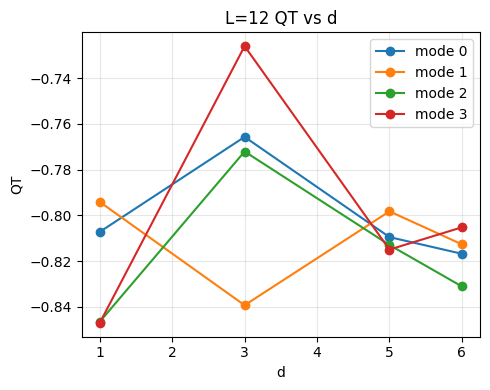

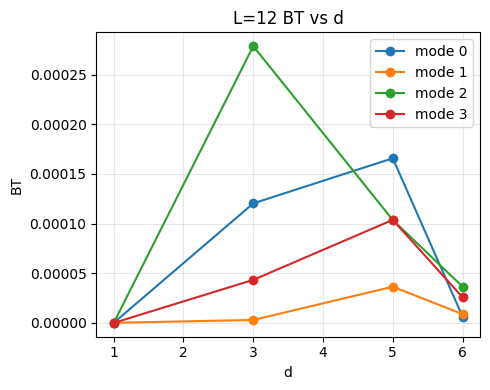

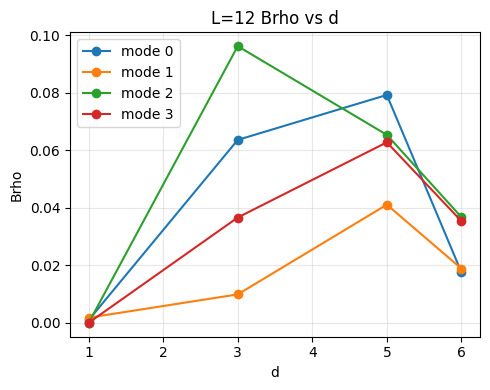

In [5]:
df_pair = run_pair_scan(CFG)
interpretation_guard(df_pair)
print_identity_summary(df_pair)
make_figures(df_pair, CFG)

In [6]:
from dataclasses import dataclass
from typing import Tuple

@dataclass
class RunConfig:
    L: int = 12
    d_list: Tuple[int, ...] = (1, 3, 5, 6)
    k: int = 4
    eig_tol: float = 1e-8
    eig_maxiter: int = 8000
    rel_residual_gate: float = 1e-6
    core_radius: float = 2.0
    bridge_radius: float = 1.5
    P_thresh: float = 0.02
    BT_thresh: float = 1e-4
    m0: float = 0.3
    v_coup: float = 2.0
    w: float = 1.0
    r_wilson: float = 1.0
    save_modes: bool = True
    use_matrix_free: bool = False  # True if sparse OOM; slower but lower peak RAM

CFG = RunConfig()

In [7]:
# ===== L=12 single-defect control =====
# Requires: algebra, hedgehog, build_sparse_H, relative_residual,
#           solve_soft_modes, gate_modes, in_ball, CFG, BASE_DIR, MASS_B, etc.

def run_single_L12(cfg, charges=(+1, -1), k=4):
    rows = []
    for ch in charges:
        label = "H" if ch > 0 else "AH"
        print(f"\n=== L={cfg.L} single {label} ===")
        c = (cfg.L//2, cfg.L//2, cfg.L//2)
        defects = [(int(ch), *c)]
        H = build_sparse_H(cfg.L, defects, cfg.m0, cfg.v_coup, cfg.w, cfg.r_wilson)
        print(f"nnz={H.nnz}")
        evals, evecs = solve_soft_modes(H, k, cfg.eig_tol, cfg.eig_maxiter)
        records = gate_modes(H, evals, evecs, cfg.rel_residual_gate)
        for j, (lam, rr, ok) in enumerate(records):
            print(f"  mode{j}: λ={lam:+.6e} rel_v={rr:.3e} accepted={ok}")
            row = {
                "L": cfg.L, "config": f"single_{label}", "d": None,
                "mode": j, "lambda": lam, "abs_lambda": abs(lam),
                "rel_residual": rr, "accepted": ok,
            }
            if ok:
                pr = evecs[:, j].reshape((cfg.L, cfg.L, cfg.L, 8))
                dens = np.sum(np.abs(pr)**2, axis=3)
                dens /= dens.sum() + 1e-30
                chiT = np.zeros_like(dens)
                for x, y, z in product(range(cfg.L), repeat=3):
                    loc = pr[x, y, z]
                    f, hx, hy, hz = hedgehog(x, y, z, *c, cfg.L, cfg.w)
                    nn = np.sqrt(hx*hx + hy*hy + hz*hz + 1e-30)
                    M = (hx/nn)*MASS_B[0] + (hy/nn)*MASS_B[1] + (hz/nn)*MASS_B[2]
                    chiT[x, y, z] = float(np.vdot(loc, M @ loc).real)
                Pcore = Xcore = 0.0
                for x, y, z in product(range(cfg.L), repeat=3):
                    if in_ball(x, y, z, c, cfg.L, cfg.core_radius):
                        Pcore += dens[x, y, z]
                        Xcore += chiT[x, y, z]
                row.update({
                    "Pcore": Pcore,
                    "t_core": Xcore / (Pcore + 1e-12),
                    "QT": float(np.sum(chiT)),
                    "IPR": float(np.sum(dens**2)),
                    "class": "single_defect",
                })
            rows.append(row)
        del H, evecs
    df = pd.DataFrame(rows)
    path = f"{BASE_DIR}/tables/L{cfg.L}_single_scan.csv"
    df.to_csv(path, index=False)
    print("Saved", path)
    return df

df_single = run_single_L12(CFG)
print(df_single[df_single["accepted"]==True][
    ["config","mode","abs_lambda","rel_residual","QT","Pcore","t_core","IPR"]
].to_string(index=False))


=== L=12 single H ===
nnz=193496
  mode0: λ=+4.457996e-04 rel_v=1.009e-13 accepted=True
  mode1: λ=-8.466011e-04 rel_v=1.713e-13 accepted=True
  mode2: λ=-8.749731e-04 rel_v=1.099e-13 accepted=True
  mode3: λ=-9.033852e-04 rel_v=1.076e-13 accepted=True

=== L=12 single AH ===
nnz=193496
  mode0: λ=+4.457996e-04 rel_v=1.163e-13 accepted=True
  mode1: λ=-8.466011e-04 rel_v=1.227e-13 accepted=True
  mode2: λ=-8.749731e-04 rel_v=1.593e-13 accepted=True
  mode3: λ=-9.033852e-04 rel_v=1.375e-13 accepted=True
Saved /content/l12_texture_bridge/tables/L12_single_scan.csv
   config  mode  abs_lambda  rel_residual        QT    Pcore    t_core      IPR
 single_H     0    0.000446  1.009302e-13 -0.838609 0.010091 -0.812600 0.000876
 single_H     1    0.000847  1.712915e-13 -0.824431 0.012089 -0.627971 0.000915
 single_H     2    0.000875  1.098831e-13 -0.835399 0.007837 -0.767887 0.000851
 single_H     3    0.000903  1.076411e-13 -0.842964 0.005697 -0.728075 0.000853
single_AH     0    0.000446  1